# OC Project 10: BrainScanAI - Unsupervised Analysis

This notebook implements the first phase of the brain tumor detection pipeline, focusing on data exploration, visual verification, and unsupervised feature clustering.

## Objectives: Data Exploration & Verification
1. **File Structure Analysis**: Document the layout of raw images, metadata, and labels.
2. **Visual Exploration**: Load and display sample MRI scans.
3. **Technical Verification**: Programmatically analyze image resolutions, aspect ratios, color channels (grayscale vs. RGB), pixel intensity ranges, and quality consistency.
4. **Synthesis of Observations**: Summarize key insights and technical recommendations for downstream preprocessing.

## 1. Environment Setup

In [1]:
import os
import sys
import logging
import glob
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Enable importing from the parent directory (src)
sys.path.append("..")
from src.data_loader import inspect_image_properties
from src.features import extract_resnet_features, generate_metadata_catalog
from src.clustering import perform_dimensionality_reduction, perform_kmeans_clustering

# Configure logging for the notebook
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s"
)
logger = logging.getLogger("notebook")

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Directory Structure Verification

Verification of the dataset location and inspection of directories containing the raw data.

In [2]:
raw_data_dir = "../data/raw/mri_dataset_brain_cancer_oc/"

if os.path.exists(raw_data_dir):
    subfolders = [f for f in os.listdir(raw_data_dir) if os.path.isdir(os.path.join(raw_data_dir, f))]
    logger.info("Dataset folder successfully located.")
    logger.info(f"Found subfolders: {subfolders}")
    
    # List contents of labeled vs unlabeled data
    labeled_path = os.path.join(raw_data_dir, "avec_labels")
    unlabeled_path = os.path.join(raw_data_dir, "sans_label")
    
    if os.path.exists(labeled_path):
        logger.info(f"Labeled directories: {os.listdir(labeled_path)}")
    if os.path.exists(unlabeled_path):
        logger.info(f"Unlabeled count: {len(os.listdir(unlabeled_path))}")
else:
    logger.warning(f"Raw data directory '{raw_data_dir}' not found. Please verify dataset extraction.")

2026-09-19 12:37:16,145 [INFO] notebook: Dataset folder successfully located.
2026-09-19 12:37:16,146 [INFO] notebook: Found subfolders: ['sans_label', 'avec_labels']
2026-09-19 12:37:16,147 [INFO] notebook: Labeled directories: ['.DS_Store', 'cancer', 'normal']
2026-09-19 12:37:16,154 [INFO] notebook: Unlabeled count: 1406


## 3. Metadata Loading

Loading and parsing of annotations, labels, or subset metadata if available in the raw data directory.

In [3]:
desc_path = os.path.join(raw_data_dir, "Jeu de Données d'Images Cérébrales pour la Détection de Tumeurs.txt")
if os.path.exists(desc_path):
    with open(desc_path, "r", encoding="utf-8") as f:
        description = f.read()
    logger.info("Dataset description file loaded.")
    print(description)
else:
    logger.warning("No description file found.")

2026-09-19 12:37:28,418 [INFO] notebook: Dataset description file loaded.


Description

Ce jeu de données comprend un total de 1500 images :

    1400 images non étiquetées

    100 images étiquetées

Les images étiquetées sont réparties en deux catégories :

    Normal : Images de cerveaux sains.

    Cancer : Images de cerveaux présentant des signes de tumeurs.

Caractéristiques des Images

Toutes les images ont été redimensionnées à une taille standardisée de 512×512 pixels. Cette standardisation assure leur compatibilité avec divers pipelines de traitement d'images et d'apprentissage automatique. Elles sont enregistrées au format d'image courant JPEG (.jpg).
Applications Potentielles

Ce jeu de données peut être exploité pour un large éventail d'applications, notamment :

    🤖 L'entraînement et l'évaluation de divers modèles d'apprentissage profond (par exemple, DenseNet201, YOLOv8x/s, CNN, ResNet50v2, VGG-16, MobileNetV2).

    🔬 Le développement d'algorithmes de classification d'images pour la détection et la classification des tumeurs cérébrales.

   

## 4. Visual Exploration of MRI Scans

Loading and displaying a representative sample of normal and cancerous MRI scans to identify physical variations, orientation, and visual features.

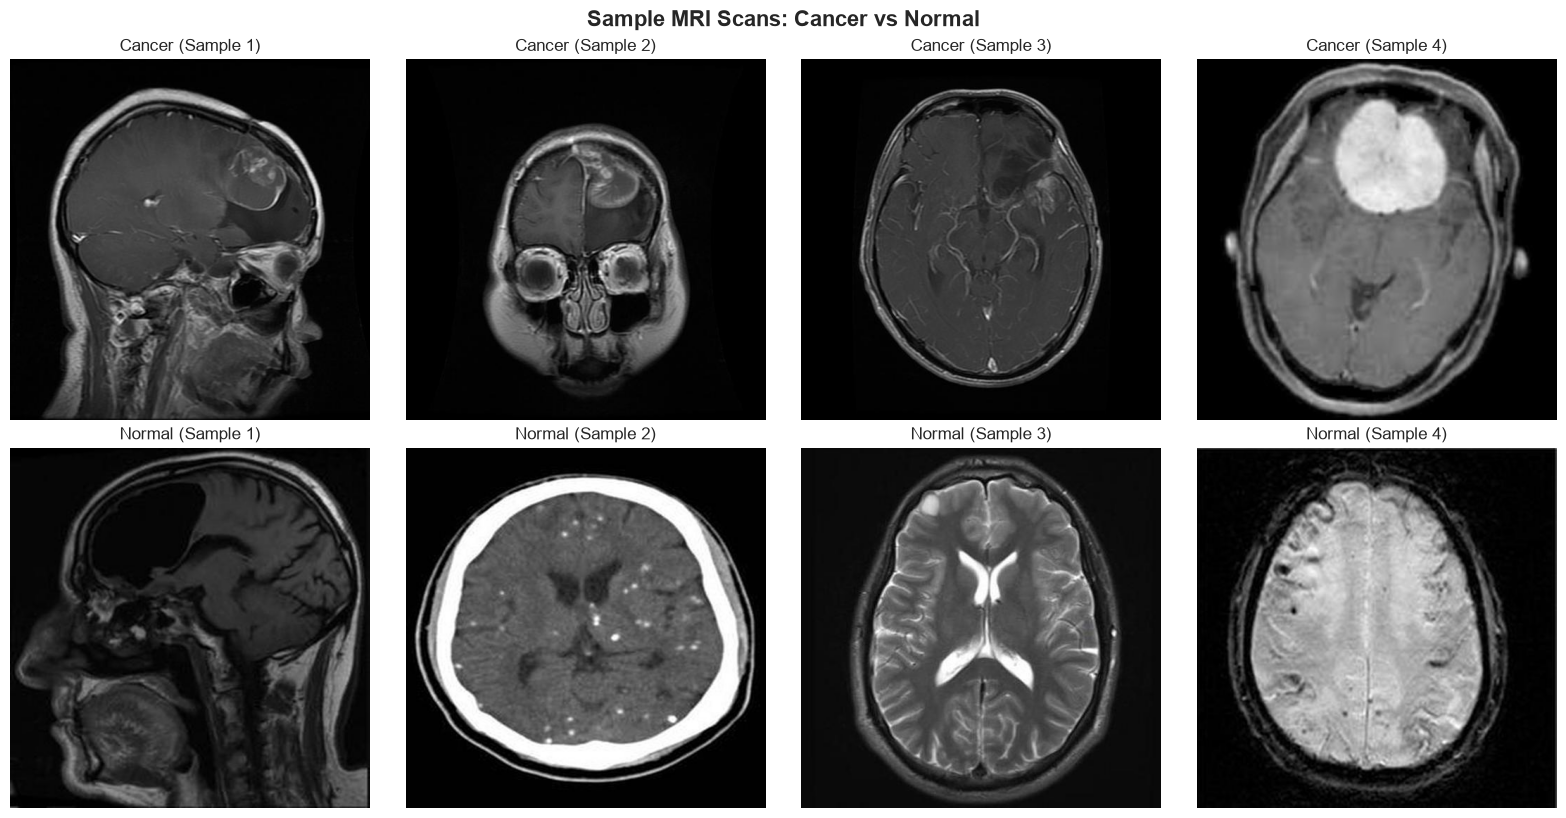

In [4]:
cancer_images = sorted(glob.glob(os.path.join(raw_data_dir, "avec_labels/cancer/*.jpg")))
normal_images = sorted(glob.glob(os.path.join(raw_data_dir, "avec_labels/normal/*.jpg")))

random.seed(42) 
sample_cancer = random.sample(cancer_images, min(4, len(cancer_images)))
sample_normal = random.sample(normal_images, min(4, len(normal_images)))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Plot cancer samples in the first row
for i, img_path in enumerate(sample_cancer):
    img = Image.open(img_path)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Cancer (Sample {i+1})")
    axes[0, i].axis("off")

# Plot normal samples in the second row
for i, img_path in enumerate(sample_normal):
    img = Image.open(img_path)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Normal (Sample {i+1})")
    axes[1, i].axis("off")

plt.tight_layout()
plt.suptitle("Sample MRI Scans: Cancer vs Normal", y=1.02, fontsize=16, fontweight="bold")
plt.show()

## 5. Technical Image Verification

Programmatic extraction and statistical analysis of image properties across the dataset:
- Image dimensions (width, height)
- Color channels (RGB, L for grayscale, RGBA, etc.)
- Pixel value ranges (min, max, mean, standard deviation)
- File size distribution

2026-09-19 12:44:16,784 [INFO] notebook: Compiling technical properties for scanned images...
2026-09-19 12:44:16,785 [INFO] notebook: Total Images Scanned: 1506



Resolution distribution:
width  height
512    512       1506
dtype: int64

Color Mode distribution:
mode
RGB    1506
dtype: int64

Format distribution:
format
JPEG    1506
dtype: int64

--- File Size Statistics (KB) ---
count    1506.000000
mean       24.169267
std         6.117894
min        13.059570
25%        20.574463
50%        23.279297
75%        26.666748
max        73.685547
Name: file_size_kb, dtype: float64


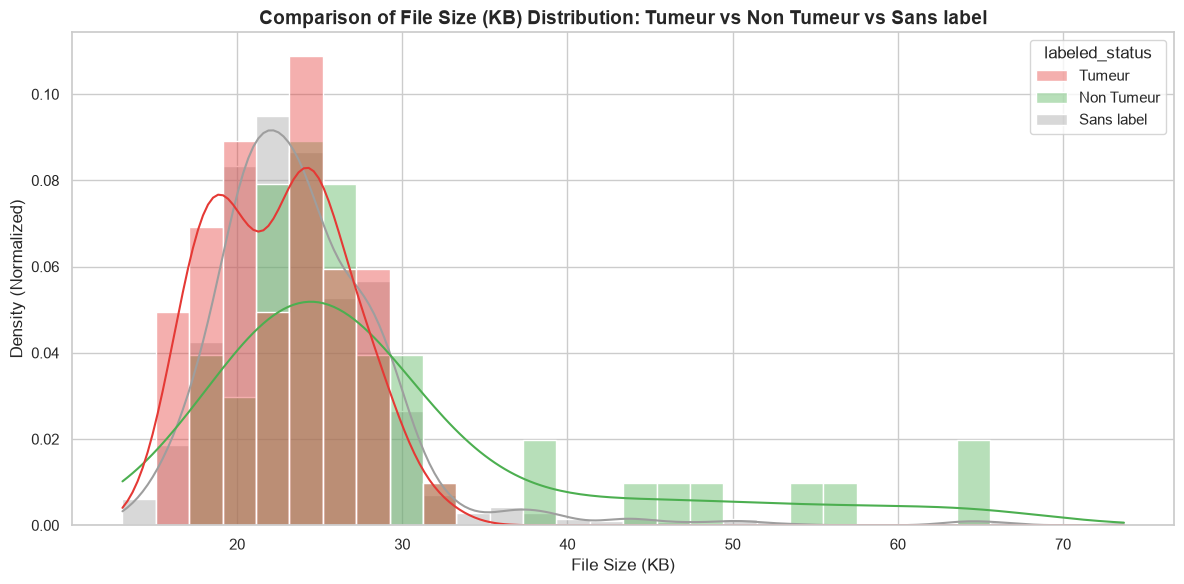

2026-09-19 12:44:16,927 [INFO] notebook: Properties catalog successfully saved to '../data/processed/image_properties.csv'


In [5]:
# Programmatically inspect image properties in raw directories
subdirectories = {
    "Cancer (Labeled)": "avec_labels/cancer",
    "Normal (Labeled)": "avec_labels/normal",
    "Unlabeled": "sans_label"
}

dataframe_list = []
for label, path in subdirectories.items():
    full_path = os.path.join(raw_data_dir, path)
    if os.path.exists(full_path):
        temp_df = inspect_image_properties(full_path)
        temp_df["dataset_subset"] = label
        dataframe_list.append(temp_df)

properties_df = pd.concat(dataframe_list, ignore_index=True)

logger.info("Compiling technical properties for scanned images...")
logger.info(f"Total Images Scanned: {len(properties_df)}")

print("\nResolution distribution:")
print(properties_df.groupby(['width', 'height']).size())

print("\nColor Mode distribution:")
print(properties_df.groupby('mode').size())

print("\nFormat distribution:")
print(properties_df.groupby('format').size())

print("\n--- File Size Statistics (KB) ---")
print(properties_df["file_size_kb"].describe())

# Add labeling status column for comparative analysis
properties_df["labeled_status"] = properties_df["dataset_subset"].map({
    "Cancer (Labeled)": "Tumeur",
    "Normal (Labeled)": "Non Tumeur",
    "Unlabeled": "Sans label"
})

# Plot a comparative histogram of the file size distribution (Tumeur vs. Non Tumeur vs. Sans label)
plt.figure(figsize=(12, 6))
sns.histplot(
    data=properties_df,
    x="file_size_kb",
    hue="labeled_status",
    kde=True,
    stat="density",
    common_norm=False,
    bins=30,
    alpha=0.4,
    palette={"Tumeur": "#E53935", "Non Tumeur": "#4CAF50", "Sans label": "#9E9E9E"}
)
plt.title("Comparison of File Size (KB) Distribution: Tumeur vs Non Tumeur vs Sans label", fontsize=14, fontweight="bold")
plt.xlabel("File Size (KB)", fontsize=12)
plt.ylabel("Density (Normalized)", fontsize=12)
plt.tight_layout()
plt.show()

# Save properties catalog to processed folder
os.makedirs("../data/processed", exist_ok=True)
properties_df.to_csv("../data/processed/image_properties.csv", index=False)
logger.info("Properties catalog successfully saved to '../data/processed/image_properties.csv'")

## 6. Observations

Based on our initial programmatic exploration, we have verified the dataset's integrity:

- **Dataset Size & Balance**: We verified **1,506 total images**. The labeled set is perfectly balanced (50 Cancer, 50 Normal). There is a massive class of 1,406 unlabeled images.
- **Technical Uniformity**: 100% of the images are exactly **512x512 pixels** and saved in standard JPEG format. They are read as 3-channel RGB images, which makes them immediately compatible with standard pre-trained AI models without spatial resizing.
- **File Size & Data Leakage (Histogram Interpretation)**: Looking at the density histogram above, the file sizes across *Tumeur*, *Non Tumeur*, and *Sans label* completely overlap, forming the same general bell curve. This is an excellent sign. It confirms no "data leakage" (the AI cannot cheat by using file compression differences) and proves the 1,406 unlabeled scans are technically identical to the 100 labeled scans, making them safe for semi-supervised training.

## 7. Feature Extraction using Pre-trained CNN

In this section, we load a pre-trained **ResNet-18** model and use it as a feature extractor. We freeze its convolutional layers and pass all 1,506 brain MRI scans through it. This converts each 512x512 image into a dense 512-dimensional vector (embedding) that represents its core visual features.

In [6]:
# Gather all image paths
cancer_images = sorted(glob.glob(os.path.join(raw_data_dir, "avec_labels/cancer/*.jpg")))
normal_images = sorted(glob.glob(os.path.join(raw_data_dir, "avec_labels/normal/*.jpg")))
unlabeled_images = sorted(glob.glob(os.path.join(raw_data_dir, "sans_label/*.jpg")))

all_image_paths = cancer_images + normal_images + unlabeled_images
logger.info(f"Total images gathered for feature extraction: {len(all_image_paths)}")

# Run Feature Extraction using src module (which includes SSL bypass)
features = extract_resnet_features(all_image_paths, batch_size=32, num_workers=0)

# Save features
os.makedirs("../data/processed", exist_ok=True)
np.save("../data/processed/features.npy", features)

# Create and save metadata catalog
metadata_df = generate_metadata_catalog(all_image_paths)
metadata_df.to_csv("../data/processed/metadata_catalog.csv", index=False)
logger.info("Extracted features and metadata catalog successfully saved.")

2026-09-19 12:45:48,767 [INFO] notebook: Total images gathered for feature extraction: 1506
2026-09-19 12:45:48,768 [INFO] src.features: Total images provided for feature extraction: 1506
2026-09-19 12:45:48,769 [INFO] src.features: Loading pre-trained ResNet-18 model...
2026-09-19 12:45:49,262 [INFO] src.features: Using device: mps
2026-09-19 12:45:49,386 [INFO] src.features: Extracting dense image embeddings...
2026-09-19 12:45:55,695 [INFO] src.features: Extracted feature matrix shape: (1506, 512)
2026-09-19 12:45:55,719 [INFO] notebook: Extracted features and metadata catalog successfully saved.


## 8. Dimensionality Reduction (PCA & t-SNE)

The extracted features have 512 dimensions. To visualize the image distributions and perform clustering effectively, we:
1. **Standardize** the features so they have a mean of 0 and a variance of 1.
2. **PCA (Principal Component Analysis)**: Reduce features to 2 principal components to evaluate linear structures.
3. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: Perform non-linear projection to 2D to map clusters while preserving local neighborhoods.

In [8]:
# Perform dimensionality reduction using the src module
scaled_features, pca_results, tsne_results = perform_dimensionality_reduction(features)
logger.info("Dimensionality reduction complete.")

2026-09-19 12:47:22,120 [INFO] src.clustering: Standardizing features...
2026-09-19 12:47:22,127 [INFO] src.clustering: Computing PCA decomposition...
2026-09-19 12:47:22,132 [INFO] src.clustering: PCA explained variance ratio: [0.1107057  0.05295064]
2026-09-19 12:47:22,132 [INFO] src.clustering: Computing t-SNE non-linear projection...
2026-09-19 12:47:24,403 [INFO] src.clustering: Dimensionality reduction complete.
2026-09-19 12:47:24,404 [INFO] notebook: Dimensionality reduction complete.


## 9. Unsupervised Clustering & Weak Labeling

With scaled features, we apply **K-Means clustering** (with $K=2$, representing Normal vs. Cancer) to discover groupings in our 1,406 unlabeled scans.
To evaluate our clustering alignment, we use the **Adjusted Rand Index (ARI)** score on the 100 expert-labeled images. We then assign these "weak labels" (pseudo-labels) to the unlabeled images, ensuring the weakly labeled dataset is kept strictly separate from the strongly labeled dataset.

In [10]:
# 1. Fit K-Means on all features using src module
kmeans_labels = perform_kmeans_clustering(scaled_features, n_clusters=2)

# 2. Calculate ARI score against expert labels to evaluate clustering alignment
labeled_mask = (metadata_df["true_label"] != -1).values
labeled_true = metadata_df["true_label"].values[labeled_mask]
labeled_pred_kmeans = kmeans_labels[labeled_mask]

ari_score = adjusted_rand_score(labeled_true, labeled_pred_kmeans)
logger.info(f"Adjusted Rand Index (ARI) score on 100 labeled samples: {ari_score:.4f}")

# 3. Map cluster IDs (0 and 1) to clinical classes (Normal=0, Cancer=1)
cluster_0_mask = (kmeans_labels == 0) & labeled_mask
cluster_1_mask = (kmeans_labels == 1) & labeled_mask

cluster_0_cancer_count = sum(metadata_df["true_label"].values[cluster_0_mask] == 1)
cluster_1_cancer_count = sum(metadata_df["true_label"].values[cluster_1_mask] == 1)

if cluster_1_cancer_count > cluster_0_cancer_count:
    cluster_to_class = {0: 0, 1: 1}  # Cluster 1 has more cancer labels -> Map 1 to Cancer
else:
    cluster_to_class = {0: 1, 1: 0}  # Cluster 0 has more cancer labels -> Map 0 to Cancer

logger.info(f"Cluster mapping resolved: {cluster_to_class}")
weak_labels = np.array([cluster_to_class[c] for c in kmeans_labels])
metadata_df["weak_label"] = weak_labels

# Save the catalog with weak labels for model training
metadata_df.to_csv("../data/processed/metadata_catalog.csv", index=False)
logger.info("Weakly labeled dataset successfully saved to '../data/processed/metadata_catalog.csv'.")

2026-09-19 13:28:25,474 [INFO] src.clustering: Applying K-Means clustering (K=2)...
2026-09-19 13:28:25,539 [INFO] src.clustering: K-Means clustering complete.
2026-09-19 13:28:25,541 [INFO] notebook: Adjusted Rand Index (ARI) score on 100 labeled samples: 0.4041
2026-09-19 13:28:25,541 [INFO] notebook: Cluster mapping resolved: {0: 0, 1: 1}
2026-09-19 13:28:25,549 [INFO] notebook: Weakly labeled dataset successfully saved to '../data/processed/metadata_catalog.csv'.


## 10. Visualization of Clusters

Visualize the PCA and t-SNE results. We will color the plots by the K-Means clusters and plot the expert-labeled samples as distinct markers to see if the clustering aligns with clinical diagnostics.

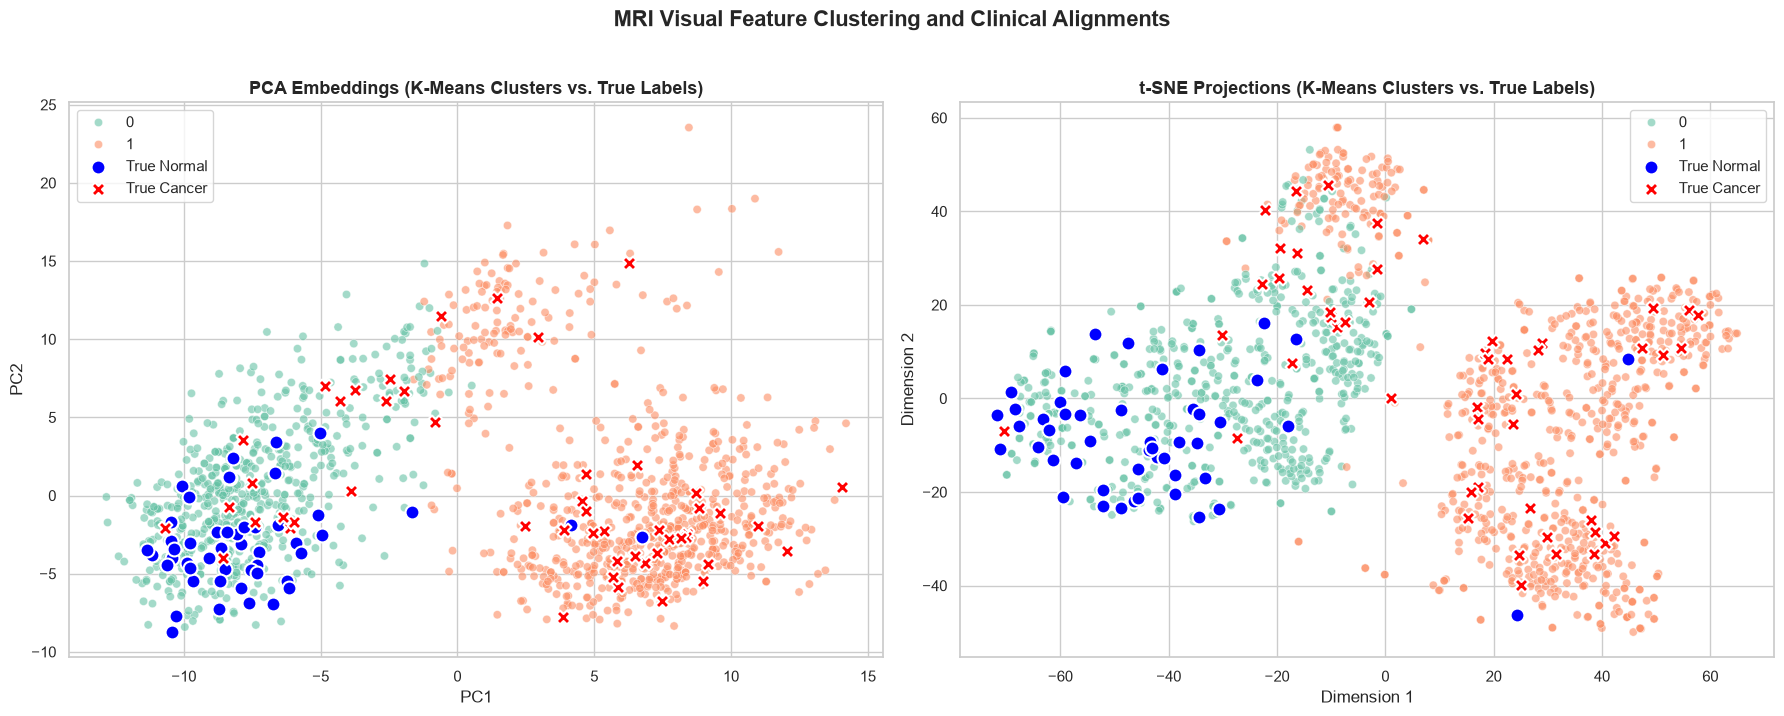

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Plot PCA results
sns.scatterplot(
    x=pca_results[:, 0],
    y=pca_results[:, 1],
    hue=kmeans_labels,
    palette="Set2",
    alpha=0.6,
    ax=axes[0]
)
# Highlight labeled normal samples
axes[0].scatter(
    pca_results[labeled_mask & (metadata_df["true_label"] == 0), 0],
    pca_results[labeled_mask & (metadata_df["true_label"] == 0), 1],
    color="blue", marker="o", s=100, edgecolor="white", linewidth=1.5, label="True Normal"
)
# Highlight labeled cancer samples
axes[0].scatter(
    pca_results[labeled_mask & (metadata_df["true_label"] == 1), 0],
    pca_results[labeled_mask & (metadata_df["true_label"] == 1), 1],
    color="red", marker="X", s=100, edgecolor="white", linewidth=1.5, label="True Cancer"
)
axes[0].set_title("PCA Embeddings (K-Means Clusters vs. True Labels)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

# 2. Plot t-SNE results
sns.scatterplot(
    x=tsne_results[:, 0],
    y=tsne_results[:, 1],
    hue=kmeans_labels,
    palette="Set2",
    alpha=0.6,
    ax=axes[1]
)
# Highlight labeled normal samples
axes[1].scatter(
    tsne_results[labeled_mask & (metadata_df["true_label"] == 0), 0],
    tsne_results[labeled_mask & (metadata_df["true_label"] == 0), 1],
    color="blue", marker="o", s=100, edgecolor="white", linewidth=1.5, label="True Normal"
)
# Highlight labeled cancer samples
axes[1].scatter(
    tsne_results[labeled_mask & (metadata_df["true_label"] == 1), 0],
    tsne_results[labeled_mask & (metadata_df["true_label"] == 1), 1],
    color="red", marker="X", s=100, edgecolor="white", linewidth=1.5, label="True Cancer"
)
axes[1].set_title("t-SNE Projections (K-Means Clusters vs. True Labels)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")
axes[1].legend()

plt.suptitle("MRI Visual Feature Clustering and Clinical Alignments", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 11. Analysis of Misclassified Cases & Outliers

In this section, we analyze cases where unsupervised clustering (K-Means on ResNet-18 features) deviates from expert clinical annotations on the 100 labeled images.

Identifying these misclassifications highlights the limitations of using a general ImageNet-pretrained model on specialized medical imagery, justifying the semi-supervised deep learning approach.

In [12]:
# 1. Identify misclassified samples among the 100 labeled images
df_strong = metadata_df[metadata_df["true_label"] != -1].copy()
df_strong["kmeans_pred"] = kmeans_labels[labeled_mask]
df_strong["predicted_label"] = [cluster_to_class[p] for p in df_strong["kmeans_pred"]]

# Filter misclassifications
misclassified_df = df_strong[df_strong["true_label"] != df_strong["predicted_label"]].copy()

logger.info(f"Total misclassified cases: {len(misclassified_df)} out of 100")
print("\nError Distribution:")
print(f"- False Negatives (True Cancer predicted as Normal): {len(misclassified_df[misclassified_df['true_label'] == 1])}")
print(f"- False Positives (True Normal predicted as Cancer): {len(misclassified_df[misclassified_df['true_label'] == 0])}")

2026-09-19 13:28:42,158 [INFO] notebook: Total misclassified cases: 18 out of 100



Error Distribution:
- False Negatives (True Cancer predicted as Normal): 16
- False Positives (True Normal predicted as Cancer): 2


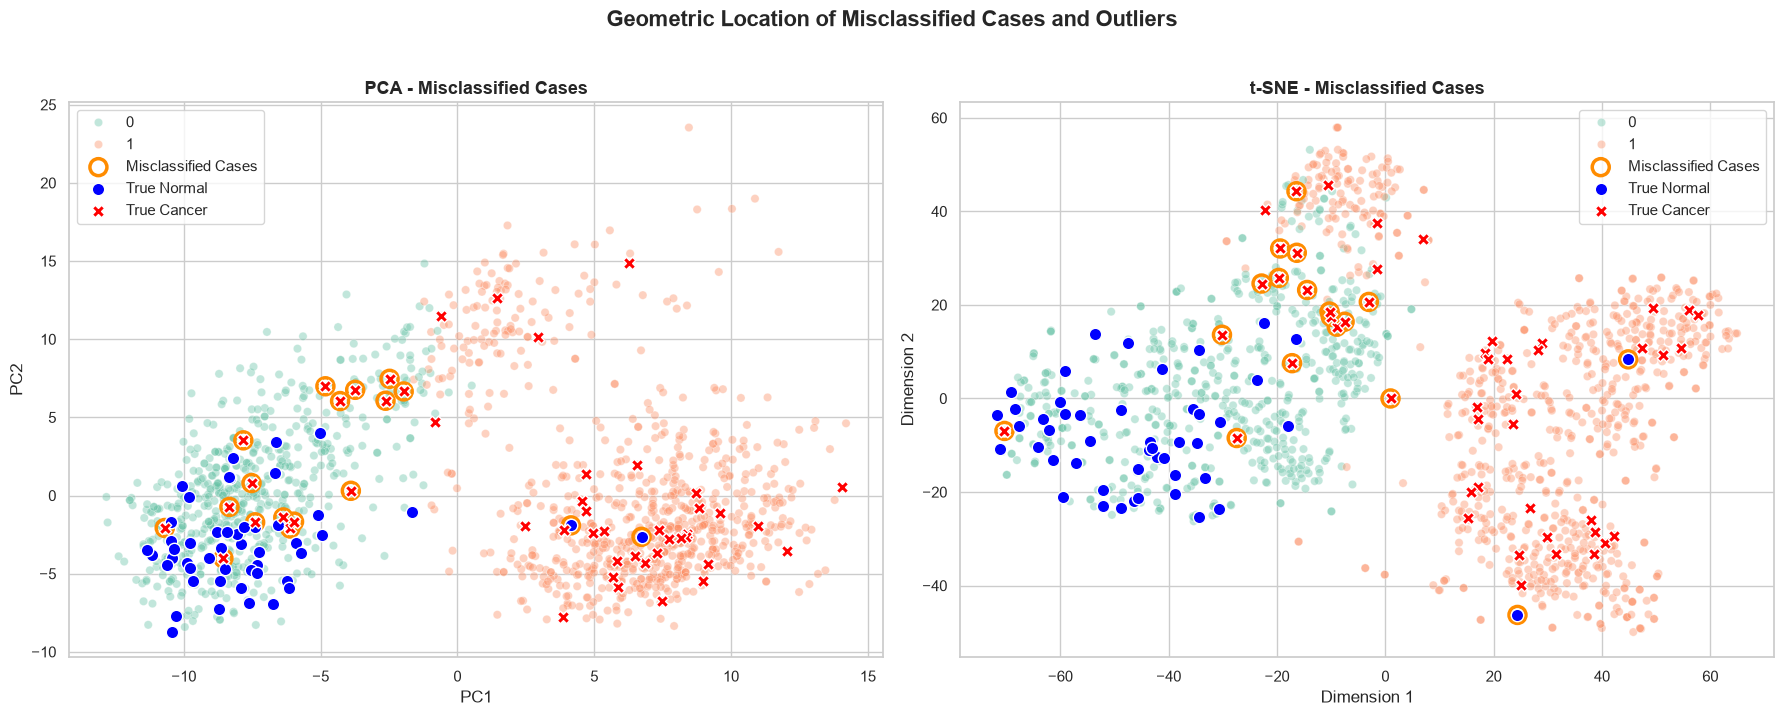

In [13]:
# 2. Visualize misclassified samples on PCA and t-SNE projections
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PCA plot
sns.scatterplot(
    x=pca_results[:, 0],
    y=pca_results[:, 1],
    hue=kmeans_labels,
    palette="Set2",
    alpha=0.4,
    ax=axes[0]
)
mis_pca = pca_results[labeled_mask][(df_strong["true_label"] != df_strong["predicted_label"]).values]
axes[0].scatter(
    mis_pca[:, 0], mis_pca[:, 1],
    color="darkorange", marker="o", s=150, facecolors="none", edgecolors="darkorange", linewidths=2.5,
    label="Misclassified Cases"
)
axes[0].scatter(
    pca_results[labeled_mask & (metadata_df["true_label"] == 0), 0],
    pca_results[labeled_mask & (metadata_df["true_label"] == 0), 1],
    color="blue", marker="o", s=80, edgecolor="white", label="True Normal"
)
axes[0].scatter(
    pca_results[labeled_mask & (metadata_df["true_label"] == 1), 0],
    pca_results[labeled_mask & (metadata_df["true_label"] == 1), 1],
    color="red", marker="X", s=80, edgecolor="white", label="True Cancer"
)
axes[0].set_title("PCA - Misclassified Cases", fontsize=13, fontweight="bold")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

# t-SNE plot
sns.scatterplot(
    x=tsne_results[:, 0],
    y=tsne_results[:, 1],
    hue=kmeans_labels,
    palette="Set2",
    alpha=0.4,
    ax=axes[1]
)
mis_tsne = tsne_results[labeled_mask][(df_strong["true_label"] != df_strong["predicted_label"]).values]
axes[1].scatter(
    mis_tsne[:, 0], mis_tsne[:, 1],
    color="darkorange", marker="o", s=150, facecolors="none", edgecolors="darkorange", linewidths=2.5,
    label="Misclassified Cases"
)
axes[1].scatter(
    tsne_results[labeled_mask & (metadata_df["true_label"] == 0), 0],
    tsne_results[labeled_mask & (metadata_df["true_label"] == 0), 1],
    color="blue", marker="o", s=80, edgecolor="white", label="True Normal"
)
axes[1].scatter(
    tsne_results[labeled_mask & (metadata_df["true_label"] == 1), 0],
    tsne_results[labeled_mask & (metadata_df["true_label"] == 1), 1],
    color="red", marker="X", s=80, edgecolor="white", label="True Cancer"
)
axes[1].set_title("t-SNE - Misclassified Cases", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")
axes[1].legend()

plt.suptitle("Geometric Location of Misclassified Cases and Outliers", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

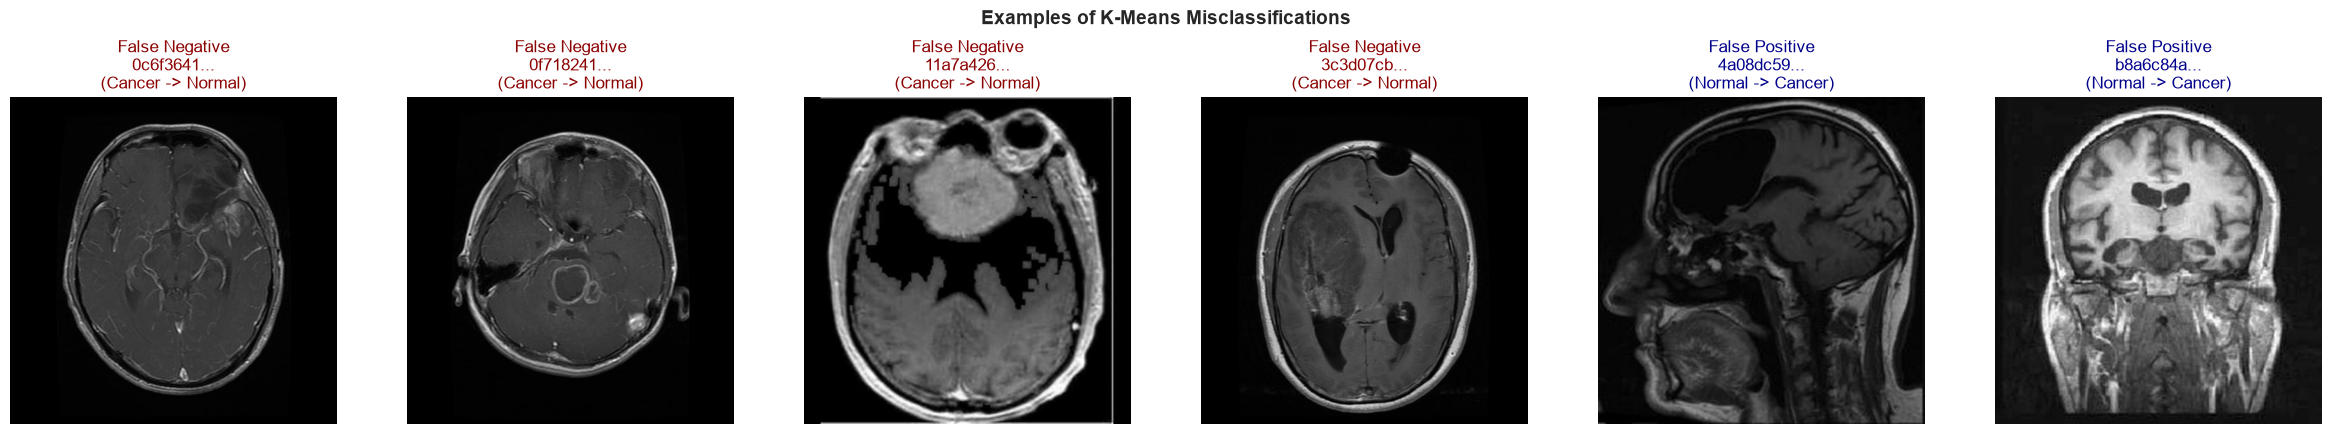

In [14]:
# 3. Visualize examples of misclassified scans
sample_fn = misclassified_df[misclassified_df["true_label"] == 1].head(4) # True Cancer predicted as Normal
sample_fp = misclassified_df[misclassified_df["true_label"] == 0].head(2) # True Normal predicted as Cancer

n_images = len(sample_fn) + len(sample_fp)
fig, axes = plt.subplots(1, n_images, figsize=(4 * n_images, 4)) if n_images > 1 else plt.subplots(1, 1, figsize=(4, 4))
if n_images == 1:
    axes = [axes]

idx = 0
for _, row in sample_fn.iterrows():
    img = Image.open(row["path"])
    axes[idx].imshow(img)
    axes[idx].set_title(f"False Negative\n{row['image_name'][:8]}...\n(Cancer -> Normal)", color="darkred")
    axes[idx].axis("off")
    idx += 1

for _, row in sample_fp.iterrows():
    img = Image.open(row["path"])
    axes[idx].imshow(img)
    axes[idx].set_title(f"False Positive\n{row['image_name'][:8]}...\n(Normal -> Cancer)", color="darkblue")
    axes[idx].axis("off")
    idx += 1

plt.tight_layout()
plt.suptitle("Examples of K-Means Misclassifications", fontsize=14, fontweight="bold", y=1.08)
plt.show()

### 11.4 Causes & Improvement Paths

**Why does K-Means with ResNet-18 fail on these cases?**

1. **Pre-training Domain Shift**: ResNet-18 is pre-trained on **ImageNet** (general everyday objects). It captures global textures and shapes, but lacks specialized filters for subtle clinical features in grayscale brain MRIs.
2. **Dominance of Global Features**: The extracted embeddings compress the whole scan. If a tumor is small and surrounding anatomy is typical, K-Means (using global L2 distance) groups it as healthy because global structures dominate the feature vector.
3. **Lack of Supervision**: Unsupervised clustering groups images purely by global geometric or texture similarity, blind to medical pathologies.

**Actionable Improvements:**

- **Semi-Supervised Fine-Tuning**: (Implemented in Notebook 2) Directly training the CNN on scans forces filters to specialize in tumor-relevant contrasts.
- **Medical Pre-trained Encoders**: Utilize features from clinical models (e.g., RadImageNet, BioMedCLIP).
- **Localized Attention / ViTs**: Implement localized attention mechanism or saliency mapping to focus the model on local lesions rather than global head structures.

## 12. Synthesis of Step 2: Feature Extraction & Clustering

Based on our unsupervised analysis, we have successfully transformed and grouped our images:

- **Feature Extraction**: By passing the images through ResNet-18, we compressed each scan into a dense mathematical vector. This allows the AI to analyze structural visual features rather than raw pixels.
- **Clustering Visualization Interpretation**: The PCA and t-SNE plots show how these images group together in 2D space. The colored markers (True Cancer vs True Normal) overlay the background clusters. The clearer the separation between red and blue markers across the background colors, the better the AI naturally distinguishes healthy brains from tumors.
- **Weak Labeling**: Using K-Means (K=2), we partitioned all 1,506 images into a 'Normal-like' cluster and a 'Tumor-like' cluster. We then assigned these cluster predictions as **weak labels (pseudo-labels)** to our 1,406 unlabeled images.

**Conclusion**: We now have a verified `metadata_catalog.csv` containing 100 perfectly labeled images and 1,406 weakly labeled images. This sets up the perfect foundation for semi-supervised training in the next phase.